# Lëk — Food Price Inflation Early Warning: Model Training

Trains and compares **five models** to predict South Sudan's food price index
**one month ahead**: Linear Regression, ARIMA, Random Forest, XGBoost, and LSTM.

**Data honesty note:** three feature sources end before the test window
(conflict/UCDP ends 2024, national CPI ends 2024, oil production ends Jan 2026)
while the test window is Jan 2025 → May 2026. Those features are forward-/zero-filled
in the test period and this limitation is reported explicitly in the comparison.

## 1. Setup
Imports, reproducibility seeds (42 everywhere), and library versions.

In [1]:
import os, json, random, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

# --- reproducibility: seed everything to 42 ---
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # quiet TensorFlow
random.seed(SEED)
np.random.seed(SEED)

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels
from statsmodels.tsa.arima.model import ARIMA

import xgboost as xgb
from xgboost import XGBRegressor

import tensorflow as tf
tf.random.set_seed(SEED)
from tensorflow import keras
from tensorflow.keras import layers

import joblib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")

print("pandas      ", pd.__version__)
print("numpy       ", np.__version__)
print("scikit-learn", sklearn.__version__)
print("statsmodels ", statsmodels.__version__)
print("xgboost     ", xgb.__version__)
print("tensorflow  ", tf.__version__)

pandas       3.0.3
numpy        2.4.6
scikit-learn 1.9.0
statsmodels  0.14.6
xgboost      3.2.0
tensorflow   2.21.0


In [2]:
# Resolve repo paths robustly whether the notebook runs from training/ or repo root.
HERE = Path.cwd().resolve()
root = HERE
while not (root / "ml-service").exists() and root != root.parent:
    root = root.parent
assert (root / "ml-service").exists(), "Could not locate repo root (no ml-service/ found)"

DATA_DIR   = root / "training" / "data"
RAW        = DATA_DIR / "raw"
MANUAL     = DATA_DIR / "manual"
PROCESSED  = DATA_DIR / "processed"
MODELS_DIR = root / "ml-service" / "models"
PROCESSED.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("repo root  :", root)
print("data dir   :", DATA_DIR)
print("models dir :", MODELS_DIR)

repo root  : /Users/apple/Documents/capstone-project/Lek/lek
data dir   : /Users/apple/Documents/capstone-project/Lek/lek/training/data
models dir : /Users/apple/Documents/capstone-project/Lek/lek/ml-service/models


## 2. Data Loading
Load all 7 datasets. For each: shape, head, dtypes, and missing-value summary.
The 250 MB UCDP global file is filtered to `country IN ('South Sudan','Sudan')`
**as it is read** (chunked) so we never hold the whole thing in memory.

In [3]:
def summarize(name, df):
    print(f"\n{'='*60}\n{name}: shape={df.shape}\n{'='*60}")
    print("dtypes (first 12):")
    print(df.dtypes.head(12).to_string())
    miss = df.isna().mean().sort_values(ascending=False)
    print("\ntop missing-value fractions:")
    print(miss.head(6).to_string())
    return df

In [4]:
# --- 2a. RTFP food prices ---
rtfp = pd.read_csv(RAW / "rtfp_food_prices.csv", low_memory=False)
summarize("RTFP food prices", rtfp)
rtfp.head(3)


RTFP food prices: shape=(9320, 123)
dtypes (first 12):
ISO3              str
country           str
adm1_name         str
adm2_name         str
mkt_name          str
lat           float64
lon           float64
geo_id            str
price_date        str
year            int64
month           int64
currency          str

top missing-value fractions:
cassava                0.956652
millet                 0.922532
sesame                 0.884764
groundnuts             0.862339
maize_meal             0.838412
livestocksheep_male    0.829936


,ISO3,country,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,price_date,year,...,l_wheat_flour,c_wheat_flour,inflation_wheat_flour,trust_wheat_flour,o_food_price_index,h_food_price_index,l_food_price_index,c_food_price_index,inflation_food_price_index,trust_food_price_index
0,SSD,South Sudan,Warrap,Twic,Abyei,9.35,28.28,gid_93500000282800000,2007-01-01,2007,...,1.43,1.55,NaN,9.3,0.01,0.01,0.01,0.01,NaN,8.8
1,SSD,South Sudan,Warrap,Twic,Abyei,9.35,28.28,gid_93500000282800000,2007-02-01,2007,...,1.49,1.50,NaN,9.3,0.01,0.01,0.01,0.01,NaN,8.8
2,SSD,South Sudan,Warrap,Twic,Abyei,9.35,28.28,gid_93500000282800000,2007-03-01,2007,...,1.46,1.50,NaN,9.3,0.01,0.01,0.01,0.01,NaN,8.8


In [5]:
# --- 2b. RTFX exchange rate ---
rtfx = pd.read_csv(RAW / "rtfx_exchange_rate.csv", low_memory=False)
summarize("RTFX exchange rate", rtfx)
rtfx.head(3)


RTFX exchange rate: shape=(9320, 33)
dtypes (first 12):
ISO3              str
country           str
adm1_name         str
adm2_name         str
mkt_name          str
lat           float64
lon           float64
geo_id            str
price_date        str
year            int64
month           int64
currency          str

top missing-value fractions:
trust_exchange_rate_unofficial                          1.000000
milling_cost_sorghum                                    0.838197
wage_non_qualified_labour_non_agricultural              0.823820
inflation_wage_non_qualified_labour_non_agricultural    0.051502
inflation_exchange_rate_unofficial                      0.051502
inflation_milling_cost_sorghum                          0.051502


,ISO3,country,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,price_date,year,...,l_milling_cost_sorghum,c_milling_cost_sorghum,inflation_milling_cost_sorghum,trust_milling_cost_sorghum,o_wage_non_qualified_labour_non_agricultural,h_wage_non_qualified_labour_non_agricultural,l_wage_non_qualified_labour_non_agricultural,c_wage_non_qualified_labour_non_agricultural,inflation_wage_non_qualified_labour_non_agricultural,trust_wage_non_qualified_labour_non_agricultural
0,SSD,South Sudan,Warrap,Twic,Abyei,9.35,28.28,gid_93500000282800000,2007-01-01,2007,...,0.46,0.49,NaN,8.9,9.45,10.61,9.00,9.82,NaN,8.3
1,SSD,South Sudan,Warrap,Twic,Abyei,9.35,28.28,gid_93500000282800000,2007-02-01,2007,...,0.48,0.48,NaN,8.9,10.19,11.02,9.35,9.73,NaN,8.3
2,SSD,South Sudan,Warrap,Twic,Abyei,9.35,28.28,gid_93500000282800000,2007-03-01,2007,...,0.46,0.50,NaN,8.9,10.05,10.75,9.35,9.87,NaN,8.3


In [6]:
# --- 2c. EIA oil production (line 1 is a 'Report generated on:' metadata row) ---
eia_raw = pd.read_csv(RAW / "eia_oil_production_monthly.csv", skiprows=1, low_memory=False)
print("EIA raw shape (wide format, months as columns):", eia_raw.shape)
print("series available:")
for _, r in eia_raw.iterrows():
    print("  ", str(r.iloc[0]), "|", str(r.iloc[1]).strip())
eia_raw.iloc[:, :4].head()

EIA raw shape (wide format, months as columns): (8, 555)
series available:
   nan | South Sudan
   nan | Production
   INTL.53-1-SSD-TBPD.M | Total petroleum and other liquids (Mb/d)
   INTL.55-1-SSD-TBPD.M | Crude oil, NGPL, and other liquids (Mb/d)
   INTL.57-1-SSD-TBPD.M | Crude oil including lease condensate (Mb/d)
   INTL.58-1-SSD-TBPD.M | NGPL (Mb/d)
   INTL.59-1-SSD-TBPD.M | Other liquids (Mb/d)
   INTL.56-1-SSD-TBPD.M | Refinery processing gain (Mb/d)


,API,Unnamed: 1,Jan 1980,Feb 1980
0,NaN,South Sudan,NaN,NaN
1,NaN,Production,NaN,NaN
2,INTL.53-1-SSD-TBPD.M,Total petroleum and other liquids (Mb/d),NaN,NaN
3,INTL.55-1-SSD-TBPD.M,"Crude oil, NGPL, and other liquids...",NaN,NaN
4,INTL.57-1-SSD-TBPD.M,Crude oil including lease cond...,--,--


In [7]:
# --- 2d. UCDP conflict: filter to South Sudan + Sudan while reading (chunked) ---
ucdp_cols = ["year", "country", "date_start", "best",
             "type_of_violence", "deaths_civilians"]
parts = []
for chunk in pd.read_csv(RAW / "ucdp_ged.csv", usecols=ucdp_cols,
                         chunksize=200_000, low_memory=False):
    parts.append(chunk[chunk["country"].isin(["South Sudan", "Sudan"])])
ucdp = pd.concat(parts, ignore_index=True)
print("UCDP filtered to SSD+SDN:", ucdp.shape)
print(ucdp["country"].value_counts().to_string())
summarize("UCDP (filtered)", ucdp)
ucdp.head(3)

UCDP filtered to SSD+SDN: (5557, 6)
country
Sudan          4556
South Sudan    1001

UCDP (filtered): shape=(5557, 6)
dtypes (first 12):
year                int64
type_of_violence    int64
country               str
date_start            str
deaths_civilians    int64
best                int64

top missing-value fractions:
year                0.0
type_of_violence    0.0
country             0.0
date_start          0.0
deaths_civilians    0.0
best                0.0


,year,type_of_violence,country,date_start,deaths_civilians,best
0,2011,1,South Sudan,2011-09-17 00:00:00.000,0,4
1,2012,3,South Sudan,2012-08-12 00:00:00.000,3,3
2,2013,3,South Sudan,2013-03-27 00:00:00.000,0,0


In [8]:
# --- 2e. WB national CPI (4 World Bank metadata rows before the header) ---
cpi_raw = pd.read_csv(RAW / "wb_national_cpi.csv", skiprows=4, low_memory=False)
summarize("WB national CPI", cpi_raw)
cpi_raw[["Country Name", "Country Code"]].head(3)


WB national CPI: shape=(266, 71)
dtypes (first 12):
Country Name          str
Country Code          str
Indicator Name        str
Indicator Code        str
1960              float64
1961              float64
1962              float64
1963              float64
1964              float64
1965              float64
1966              float64
1967              float64

top missing-value fractions:
Unnamed: 70    1.000000
2025           1.000000
1960           0.763158
1961           0.755639
1962           0.748120
1963           0.748120


,Country Name,Country Code
0,Aruba,ABW
1,Africa Eastern and Southern,AFE
2,Afghanistan,AFG


In [9]:
# --- 2f. pipeline status (manual) ---
pipeline = pd.read_csv(MANUAL / "pipeline_status.csv")
summarize("pipeline_status", pipeline)
pipeline.head(3)


pipeline_status: shape=(233, 2)
dtypes (first 12):
date                  str
pipeline_flowing    int64

top missing-value fractions:
date                0.0
pipeline_flowing    0.0


,date,pipeline_flowing
0,2007-01-01,1
1,2007-02-01,1
2,2007-03-01,1


In [10]:
# --- 2g. seasonal calendar (manual, keyed by month 1-12) ---
seasonal = pd.read_csv(MANUAL / "seasonal_calendar.csv")
summarize("seasonal_calendar", seasonal)
seasonal


seasonal_calendar: shape=(12, 3)
dtypes (first 12):
month             int64
is_lean_season    int64
season              str

top missing-value fractions:
month             0.0
is_lean_season    0.0
season            0.0


,month,is_lean_season,season
0,1,0,dry
1,2,0,dry
2,3,0,dry
3,4,0,rainy
4,5,1,rainy
5,6,1,rainy
6,7,1,rainy
7,8,0,rainy
8,9,0,rainy
9,10,0,harvest


## 3. Cleaning and Monthly Aggregation
Each source is reduced to one row per calendar month (`date` = first of month).

- **RTFP / RTFX:** mean across the 40 markets per month.
- **EIA oil:** melt the wide month-columns to long; use the headline
  *Total petroleum and other liquids* series (`INTL.53-1-SSD-TBPD.M`).
- **UCDP:** monthly event counts and summed `best` deaths, **separately** for
  South Sudan and Sudan.
- **WB CPI:** annual → forward-filled to monthly.
- **pipeline / seasonal:** already monthly / keyed by month.

In [11]:
COMMODITIES = ["beans","cassava","groundnuts","livestockgoat_male","livestocksheep_male",
               "maize","maize_meal","millet","oil","salt","sesame","sorghum","sugar","wheat_flour"]

def to_month(df):
    d = pd.to_datetime(df["price_date"])
    return d.dt.to_period("M").dt.to_timestamp()

# --- RTFP monthly: mean across markets ---
rtfp = rtfp.copy()
rtfp["date"] = to_month(rtfp)
commodity_close = [f"c_{c}" for c in COMMODITIES]      # close columns are fully populated
rtfp_cols = ["c_food_price_index", "inflation_food_price_index"] + commodity_close
rtfp_m = rtfp.groupby("date")[rtfp_cols].mean().reset_index()
# forward-fill small gaps within the food-price time series
rtfp_m[rtfp_cols] = rtfp_m[rtfp_cols].ffill()
print("RTFP monthly:", rtfp_m.shape, rtfp_m["date"].min().date(), "->", rtfp_m["date"].max().date())
rtfp_m.head(3)

RTFP monthly: (233, 17) 2007-01-01 -> 2026-05-01


,date,c_food_price_index,inflation_food_price_index,c_beans,c_cassava,c_groundnuts,c_livestockgoat_male,c_livestocksheep_male,c_maize,c_maize_meal,c_millet,c_oil,c_salt,c_sesame,c_sorghum,c_sugar,c_wheat_flour
0,2007-01-01,0.0105,NaN,5.38100,3.51950,4.50525,96.4875,72.64925,3.1410,2.50275,4.24175,2.97400,2.17900,5.49450,3.55075,2.7795,1.93700
1,2007-02-01,0.0105,NaN,5.34175,3.44225,4.43150,94.5220,71.11575,3.0050,2.43025,4.13950,2.85700,2.11775,5.34200,3.43375,2.6985,1.85375
2,2007-03-01,0.0105,NaN,5.35375,3.47025,4.50300,95.4655,71.81250,2.9955,2.45150,4.15675,2.88525,2.14000,5.33525,3.39925,2.7250,1.87825


In [12]:
# --- RTFX monthly: mean unofficial exchange rate across markets ---
rtfx = rtfx.copy()
rtfx["date"] = to_month(rtfx)
rtfx_m = rtfx.groupby("date")["c_exchange_rate_unofficial"].mean().reset_index()
rtfx_m = rtfx_m.rename(columns={"c_exchange_rate_unofficial": "exchange_rate"})
rtfx_m["exchange_rate"] = rtfx_m["exchange_rate"].ffill()
print("RTFX monthly:", rtfx_m.shape)
rtfx_m.head(3)

RTFX monthly: (233, 2)


,date,exchange_rate
0,2007-01-01,3.19
1,2007-02-01,3.18
2,2007-03-01,3.18


In [13]:
# --- EIA oil monthly: melt wide -> long, take the headline production series ---
SERIES_API = "INTL.53-1-SSD-TBPD.M"   # Total petroleum and other liquids (Mb/d)
row = eia_raw[eia_raw.iloc[:, 0] == SERIES_API]
month_cols = [c for c in eia_raw.columns if c not in ("API", "Unnamed: 1")]
oil = row[month_cols].T.reset_index()
oil.columns = ["month_label", "oil_production"]
oil["date"] = pd.to_datetime(oil["month_label"], format="%b %Y").dt.to_period("M").dt.to_timestamp()
oil["oil_production"] = pd.to_numeric(
    oil["oil_production"].replace({"--": np.nan, "": np.nan}), errors="coerce")
oil_m = oil[["date", "oil_production"]].sort_values("date").reset_index(drop=True)
print("EIA oil monthly:", oil_m.shape, "| last non-null:",
      oil_m.dropna(subset=["oil_production"])["date"].max().date())
oil_m.tail(3)

EIA oil monthly: (553, 2) | last non-null: 2026-01-01


,date,oil_production
550,2025-11-01,130.0
551,2025-12-01,120.0
552,2026-01-01,100.0


In [14]:
# --- UCDP monthly: event counts + summed 'best' deaths, per country ---
ucdp = ucdp.copy()
ucdp["date"] = pd.to_datetime(ucdp["date_start"], errors="coerce").dt.to_period("M").dt.to_timestamp()
ucdp = ucdp.dropna(subset=["date"])
agg = (ucdp.groupby(["country", "date"])
            .agg(events=("best", "size"), deaths=("best", "sum"))
            .reset_index())
piv = agg.pivot(index="date", columns="country", values=["events", "deaths"])
piv.columns = [f"{m}_{'ssd' if c=='South Sudan' else 'sdn'}" for m, c in piv.columns]
piv = piv.rename(columns={"events_ssd": "conflict_events_ssd", "deaths_ssd": "conflict_deaths_ssd",
                          "events_sdn": "conflict_events_sdn", "deaths_sdn": "conflict_deaths_sdn"})
conflict_m = piv.reset_index()
print("UCDP monthly:", conflict_m.shape, "| last month:", conflict_m["date"].max().date())
conflict_m.tail(3)

UCDP monthly: (418, 5) | last month: 2024-12-01


,date,conflict_events_ssd,conflict_events_sdn,conflict_deaths_ssd,conflict_deaths_sdn
415,2024-10-01,NaN,76.0,NaN,1332.0
416,2024-11-01,NaN,64.0,NaN,734.0
417,2024-12-01,2.0,79.0,36.0,861.0


In [15]:
# --- WB CPI: annual -> monthly forward-fill (South Sudan, code SSD) ---
year_cols = [c for c in cpi_raw.columns if str(c).isdigit()]
ssd_cpi = cpi_raw[cpi_raw["Country Code"] == "SSD"]
cpi_long = ssd_cpi[year_cols].T.reset_index()
cpi_long.columns = ["year", "national_cpi"]
cpi_long["year"] = cpi_long["year"].astype(int)
cpi_long["national_cpi"] = pd.to_numeric(cpi_long["national_cpi"], errors="coerce")
cpi_long = cpi_long.dropna(subset=["national_cpi"])
print("CPI annual points:", len(cpi_long), "years",
      cpi_long['year'].min(), "->", cpi_long['year'].max())
cpi_long.tail(3)

CPI annual points: 16 years 2009 -> 2024


,year,national_cpi
62,2022,-6.687321
63,2023,2.382804
64,2024,91.440822


In [16]:
# --- pipeline monthly ---
pipeline = pipeline.copy()
pipeline["date"] = pd.to_datetime(pipeline["date"]).dt.to_period("M").dt.to_timestamp()
pipeline_m = (pipeline.set_index("date")["pipeline_flowing"]
              .resample("MS").last().ffill().reset_index())
print("pipeline monthly:", pipeline_m.shape)
pipeline_m.head(3)

pipeline monthly: (233, 2)


,date,pipeline_flowing
0,2007-01-01,1
1,2007-02-01,1
2,2007-03-01,1


## 4. Master Monthly Table
Join all 7 sources onto a **Jan 2007 → May 2026** monthly spine.
Target `y_next_month` = `c_food_price_index` shifted by -1 (predict *next* month).
Stale features (oil, conflict, CPI) are forward-/zero-filled past their end dates.
Saved to `training/data/processed/master_monthly.csv`.

In [17]:
# monthly spine Jan 2007 -> May 2026
spine = pd.DataFrame({"date": pd.date_range("2007-01-01", "2026-05-01", freq="MS")})
m = (spine
     .merge(rtfp_m, on="date", how="left")
     .merge(rtfx_m, on="date", how="left")
     .merge(oil_m, on="date", how="left")
     .merge(conflict_m, on="date", how="left"))
m["year"]  = m["date"].dt.year
m["month"] = m["date"].dt.month

# CPI by year (annual -> monthly via merge on year, then ffill)
m = m.merge(cpi_long, on="year", how="left")
# seasonal by month-of-year
m = m.merge(seasonal, on="month", how="left")
# pipeline by date
m = m.merge(pipeline_m, on="date", how="left")
print("joined shape:", m.shape)

joined shape: (233, 29)


In [18]:
# --- fill stale / structural gaps honestly ---
# conflict: no recorded events => 0 (also covers post-2024 gap)
conflict_cols = ["conflict_events_ssd","conflict_deaths_ssd","conflict_events_sdn","conflict_deaths_sdn"]
m[conflict_cols] = m[conflict_cols].fillna(0.0)
# oil: forward-fill, then backfill leading pre-production months to 0
m["oil_production"] = m["oil_production"].ffill().fillna(0.0)
# CPI: forward-fill annual values across months, backfill the early gap
m["national_cpi"] = m["national_cpi"].ffill().bfill()
# pipeline: assume flowing if unknown
m["pipeline_flowing"] = m["pipeline_flowing"].ffill().fillna(1).astype(int)

# target: next month's food price index
m = m.sort_values("date").reset_index(drop=True)
m["y_next_month"] = m["c_food_price_index"].shift(-1)

# drop the final row (target is NaN by construction)
master = m.dropna(subset=["y_next_month"]).reset_index(drop=True)
print("master shape:", master.shape)
print("date range:", master["date"].min().date(), "->", master["date"].max().date())
print("columns:", list(master.columns))

master shape: (232, 30)
date range: 2007-01-01 -> 2026-04-01
columns: ['date', 'c_food_price_index', 'inflation_food_price_index', 'c_beans', 'c_cassava', 'c_groundnuts', 'c_livestockgoat_male', 'c_livestocksheep_male', 'c_maize', 'c_maize_meal', 'c_millet', 'c_oil', 'c_salt', 'c_sesame', 'c_sorghum', 'c_sugar', 'c_wheat_flour', 'exchange_rate', 'oil_production', 'conflict_events_ssd', 'conflict_events_sdn', 'conflict_deaths_ssd', 'conflict_deaths_sdn', 'year', 'month', 'national_cpi', 'is_lean_season', 'season', 'pipeline_flowing', 'y_next_month']


In [19]:
# save + sanity assert on key columns
master.to_csv(PROCESSED / "master_monthly.csv", index=False)
print("saved ->", PROCESSED / "master_monthly.csv")

key_cols = ["c_food_price_index", "exchange_rate", "y_next_month"]
miss = master[key_cols].isna().mean()
print("\nkey-column missing fractions:\n", miss.to_string())
assert (miss < 0.05).all(), f"key columns exceed 5% missing: {miss.to_dict()}"
print("\nOK: all key columns < 5% missing")

saved -> /Users/apple/Documents/capstone-project/Lek/lek/training/data/processed/master_monthly.csv

key-column missing fractions:
 c_food_price_index    0.0
exchange_rate         0.0
y_next_month          0.0

OK: all key columns < 5% missing


## 5. Feature Engineering
Lags & rolling means of the food index, exchange-rate lags, oil lag,
**lagged** conflict signals (SSD + SDN), pipeline flag, seasonal calendar,
and month-of-year one-hot. Rows that become NaN from lagging are dropped.

In [20]:
f = master.copy()

# food price index lags + rolling means
for lag in [1, 3, 6, 12]:
    f[f"fpi_lag{lag}"] = f["c_food_price_index"].shift(lag)
f["fpi_roll3"] = f["c_food_price_index"].rolling(3).mean()
f["fpi_roll6"] = f["c_food_price_index"].rolling(6).mean()

# exchange rate + lags
for lag in [1, 3]:
    f[f"fx_lag{lag}"] = f["exchange_rate"].shift(lag)

# oil production lag 1
f["oil_lag1"] = f["oil_production"].shift(1)

# conflict lag 1 (SSD and SDN)
for c in ["conflict_events_ssd","conflict_deaths_ssd","conflict_events_sdn","conflict_deaths_sdn"]:
    f[f"{c}_lag1"] = f[c].shift(1)

# seasonal: ordinal encode the 'season' string
season_map = {s: i for i, s in enumerate(sorted(f["season"].dropna().unique()))}
f["season_ord"] = f["season"].map(season_map)
f["is_lean_season"] = f["is_lean_season"].astype(int)

# month-of-year one-hot
month_oh = pd.get_dummies(f["month"], prefix="m").astype(int)
f = pd.concat([f, month_oh], axis=1)

# drop rows with NaN introduced by lagging (first 12 months)
before = len(f)
f = f.dropna().reset_index(drop=True)
print(f"dropped {before - len(f)} rows from lagging; remaining {len(f)}")

FEATURES = (["c_food_price_index", "inflation_food_price_index"]
            + [f"c_{c}" for c in COMMODITIES]
            + ["exchange_rate", "oil_production", "national_cpi", "pipeline_flowing",
               "is_lean_season", "season_ord"]
            + [f"fpi_lag{l}" for l in [1,3,6,12]] + ["fpi_roll3","fpi_roll6"]
            + ["fx_lag1","fx_lag3","oil_lag1"]
            + [f"{c}_lag1" for c in ["conflict_events_ssd","conflict_deaths_ssd",
                                     "conflict_events_sdn","conflict_deaths_sdn"]]
            + list(month_oh.columns))
TARGET = "y_next_month"
print("feature matrix:", f[FEATURES].shape, "| n_features:", len(FEATURES))

dropped 12 rows from lagging; remaining 220
feature matrix: (220, 47) | n_features: 47


## 5.5 Data Visualization and Data Engineering

The data engineering pipeline (Sections 2–5) merges **7 raw sources** into one
monthly table: market-mean food prices & exchange rate, melted EIA oil output,
monthly conflict counts/deaths (UCDP), forward-filled annual CPI, pipeline status,
and the seasonal calendar — then adds lag, rolling-mean, and one-hot features.

The visualizations below characterise that engineered data: the target's trajectory,
variable distributions, feature–target correlations, and seasonality.

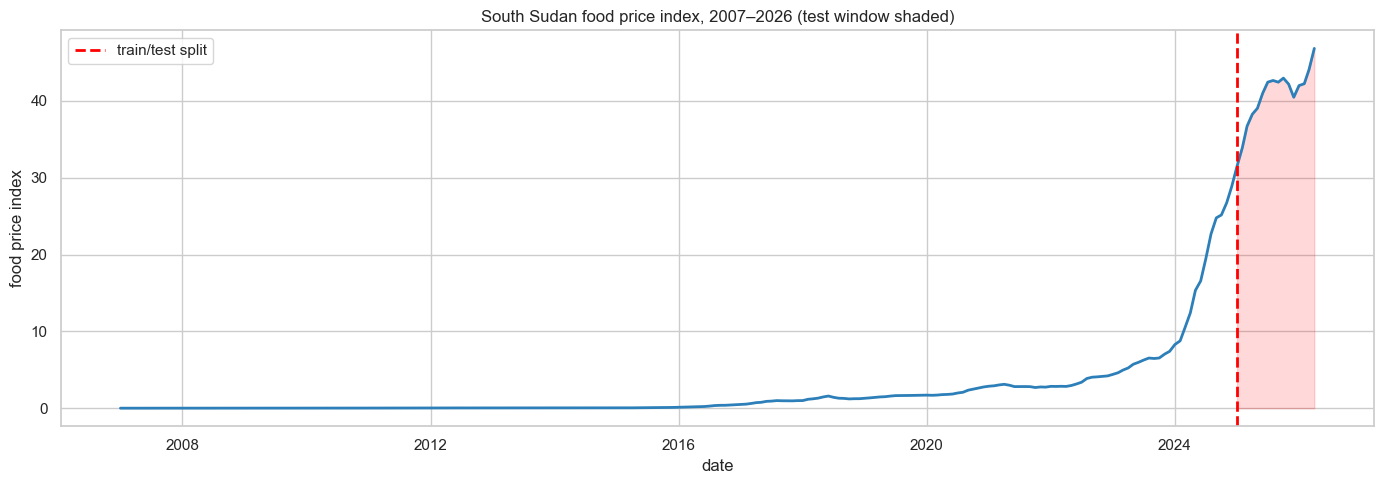

Note the steep upward trend: every test-period value sits above the entire training range — a key driver of model behaviour in Section 12.


In [21]:
# (a) Target trajectory with the train/test boundary — motivates the modeling story
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(master["date"], master["c_food_price_index"], color="#2c7fb8", lw=2)
ax.axvline(pd.Timestamp("2025-01-01"), color="red", ls="--", lw=2, label="train/test split")
ax.fill_between(master["date"], 0, master["c_food_price_index"],
                where=master["date"] >= pd.Timestamp("2025-01-01"), alpha=0.15, color="red")
ax.set_title("South Sudan food price index, 2007–2026 (test window shaded)")
ax.set_xlabel("date"); ax.set_ylabel("food price index"); ax.legend()
plt.tight_layout(); plt.show()
print("Note the steep upward trend: every test-period value sits above the entire "
      "training range — a key driver of model behaviour in Section 12.")

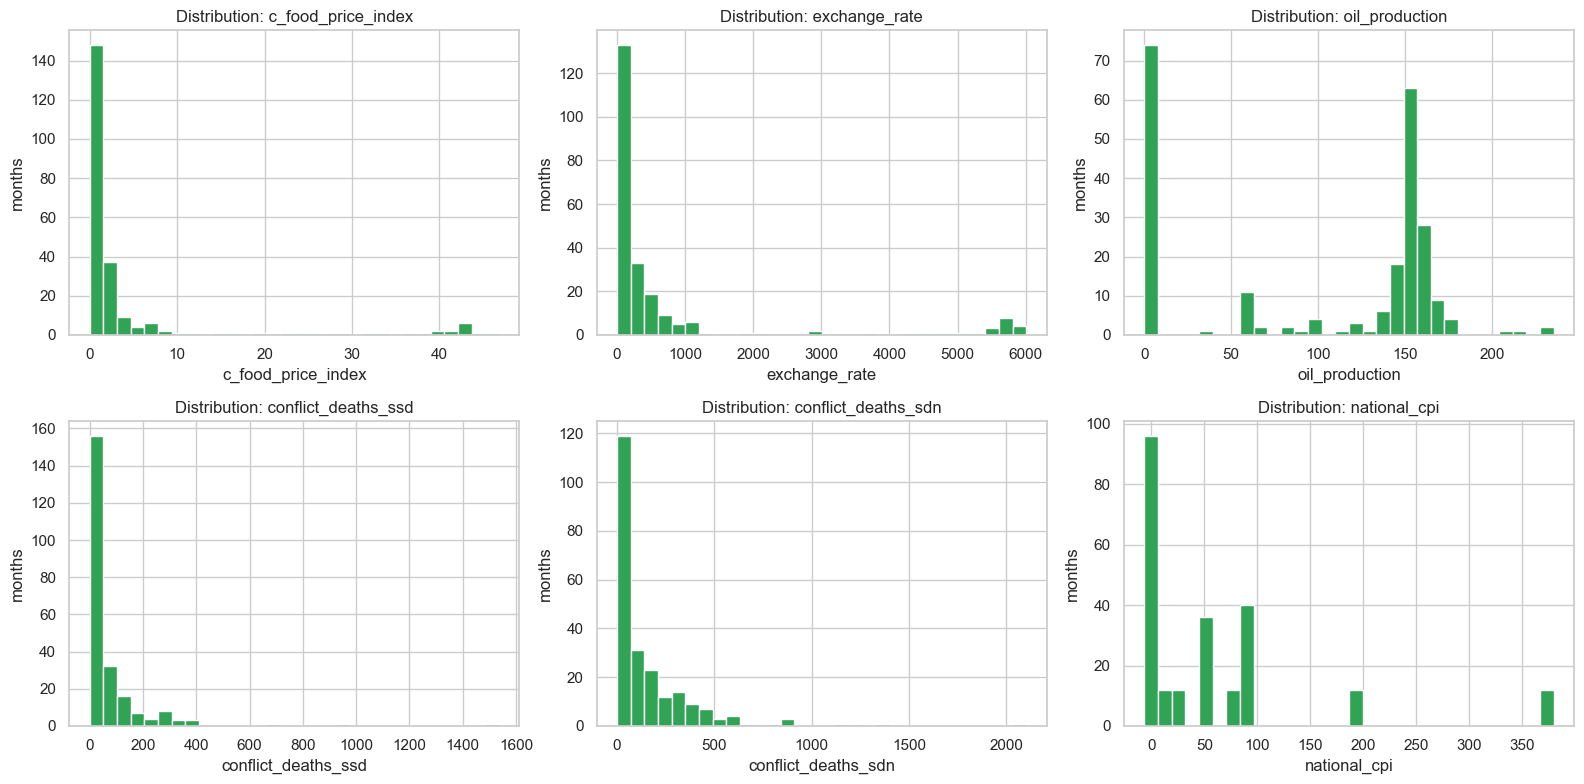

In [22]:
# (b) Distributions of the key engineered variables
key = ["c_food_price_index", "exchange_rate", "oil_production",
       "conflict_deaths_ssd", "conflict_deaths_sdn", "national_cpi"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), key):
    ax.hist(master[col].dropna(), bins=30, color="#31a354", edgecolor="white")
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel(col); ax.set_ylabel("months")
plt.tight_layout(); plt.show()

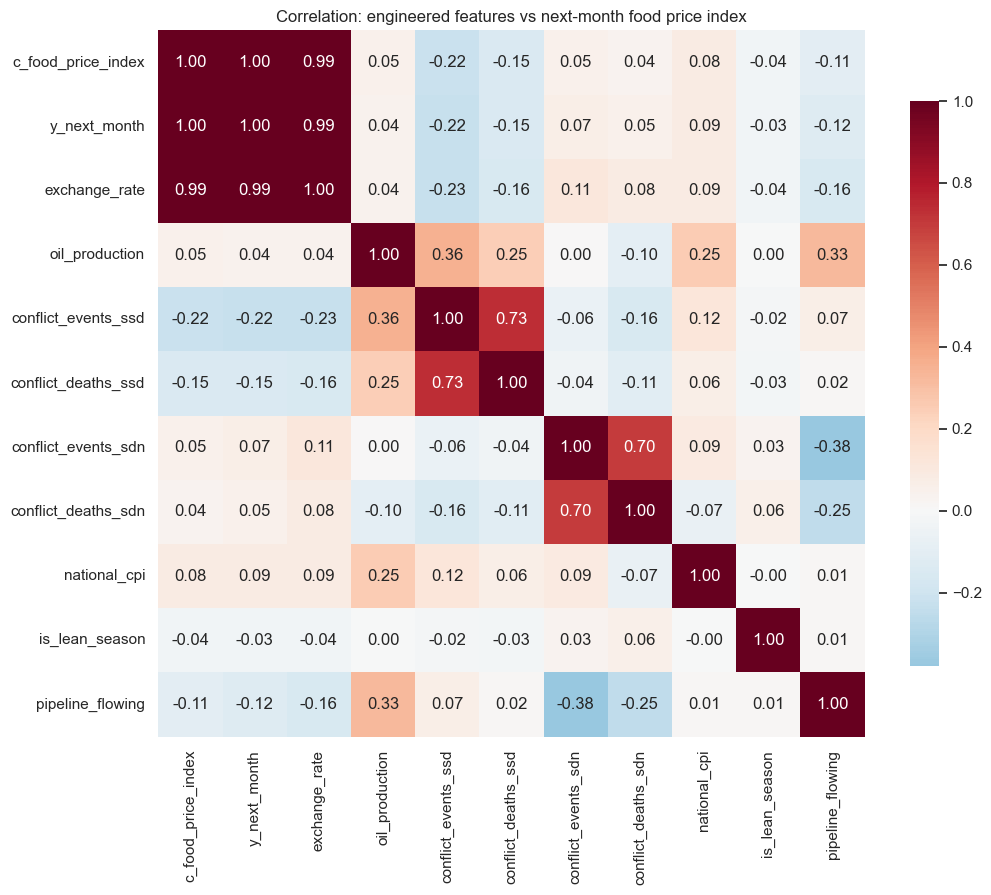

In [23]:
# (c) Correlation matrix — features vs the next-month target
corr_cols = ["c_food_price_index", "y_next_month", "exchange_rate", "oil_production",
             "conflict_events_ssd", "conflict_deaths_ssd",
             "conflict_events_sdn", "conflict_deaths_sdn",
             "national_cpi", "is_lean_season", "pipeline_flowing"]
corr = f[corr_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation: engineered features vs next-month food price index")
plt.tight_layout(); plt.show()

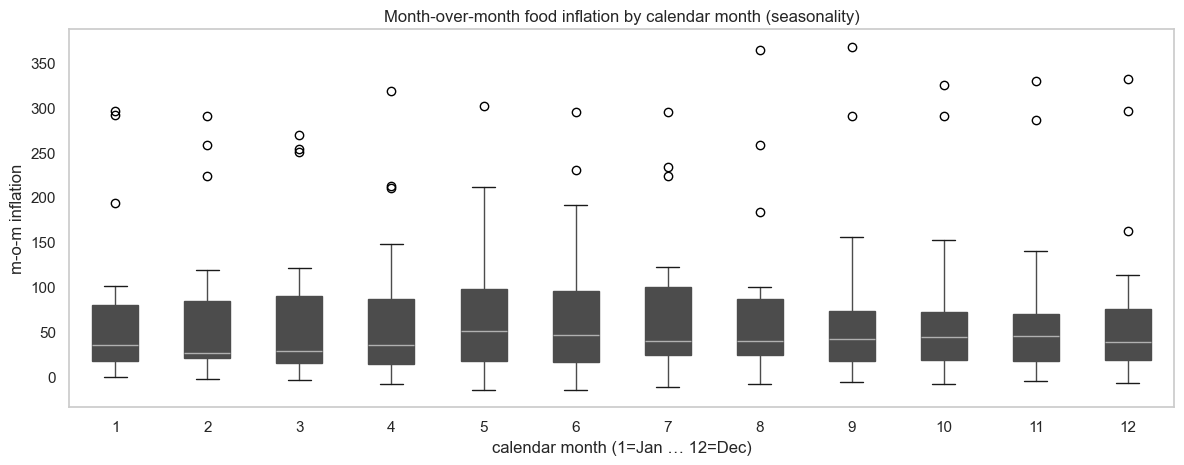

In [24]:
# (d) Seasonality — month-over-month food inflation by calendar month
fig, ax = plt.subplots(figsize=(12, 5))
master.boxplot(column="inflation_food_price_index", by="month", ax=ax,
               grid=False, patch_artist=True)
ax.set_title("Month-over-month food inflation by calendar month (seasonality)")
ax.set_xlabel("calendar month (1=Jan … 12=Dec)"); ax.set_ylabel("m-o-m inflation")
plt.suptitle("")
plt.tight_layout(); plt.show()

## 6. Train / Test Split
Time-based: **train ≤ Dec 2024**, **test = Jan 2025 → May 2026**.
`TimeSeriesSplit(5)` is used for cross-validation within training.

In [25]:
split_date = pd.Timestamp("2025-01-01")
train_mask = f["date"] < split_date
test_mask  = f["date"] >= split_date

X_train, y_train = f.loc[train_mask, FEATURES].values, f.loc[train_mask, TARGET].values
X_test,  y_test  = f.loc[test_mask,  FEATURES].values, f.loc[test_mask,  TARGET].values
dates_train = f.loc[train_mask, "date"].values
dates_test  = f.loc[test_mask,  "date"].values

# scaled views (for linear + LSTM)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

tscv = TimeSeriesSplit(n_splits=5)
print("train:", X_train.shape, "test:", X_test.shape)
print("test months:", pd.to_datetime(dates_test).min().date(), "->",
      pd.to_datetime(dates_test).max().date())

train: (204, 47) test: (16, 47)
test months: 2025-01-01 -> 2026-04-01


In [26]:
# shared metric helper + results store
def metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask])) * 100)
    r2   = float(r2_score(y_true, y_pred))
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}

results = {}      # name -> metrics dict
predictions = {}  # name -> array aligned with dates_test

## Model Architectures Overview

| Model | Architecture | Activation / Key settings | Optimization |
|---|---|---|---|
| **Linear Regression** | OLS on 47 standardized features | — | closed-form least squares |
| **ARIMA** | Univariate ARIMA(p,d,q) on the food-price-index series | differencing order *d* captures trend | AIC grid search, MLE |
| **Random Forest** | 200 trees, max depth 10 | — | bagging, MSE split criterion |
| **XGBoost** | 300 boosted trees, depth 6, lr 0.05 | — | gradient boosting + early stopping (RMSE) |
| **LSTM** | Input(12×47) → LSTM(64, seq) → Dropout(0.2) → LSTM(32) → Dropout(0.2) → Dense(1) | tanh/sigmoid gates (LSTM), linear output | Adam, MSE loss, EarlyStopping(patience 8) |

Sequence length for the LSTM is **12 months**; all models use seed **42** for reproducibility.

## 7. Model 1 — Linear Regression (baseline)

In [27]:
lin = LinearRegression().fit(X_train_s, y_train)
pred_lin = lin.predict(X_test_s)
results["LinearRegression"] = metrics(y_test, pred_lin)
predictions["LinearRegression"] = pred_lin
print(results["LinearRegression"])

{'RMSE': 10.04207793150386, 'MAE': 9.014755179288095, 'MAPE': 21.369691359654087, 'R2': -7.418941605965207}


## 8. Model 2 — ARIMA (univariate)
Small AIC grid search over `p∈{0,1,2}, d∈{0,1}, q∈{0,1,2}` on the training
`c_food_price_index` series, then **rolling one-step** forecasts across the test
window (refit each step with the realised history) for a fair next-month comparison.

In [28]:
# univariate series of the food price index, indexed by month
fpi = f.set_index("date")["c_food_price_index"].asfreq("MS")
fpi_train = fpi[fpi.index < split_date]

best_aic, best_order = np.inf, None
for p in [0,1,2]:
    for d in [0,1]:
        for q in [0,1,2]:
            try:
                res = ARIMA(fpi_train, order=(p,d,q)).fit()
                if res.aic < best_aic:
                    best_aic, best_order = res.aic, (p,d,q)
            except Exception:
                continue
print("best ARIMA order:", best_order, "| AIC=%.1f" % best_aic)

best ARIMA order: (1, 1, 2) | AIC=36.0


In [29]:
# rolling one-step forecast over the test target months
test_target_dates = (pd.to_datetime(dates_test) + pd.offsets.MonthBegin(1))
history = list(fpi[fpi.index <= pd.to_datetime(dates_test).min()].values)  # known through first test month
pred_arima = []
for tgt in test_target_dates:
    fit = ARIMA(history, order=best_order).fit()
    yhat = float(np.asarray(fit.forecast(1)).ravel()[0])
    pred_arima.append(yhat)
    actual = float(fpi.get(tgt, history[-1]))  # realised index at target month
    history.append(actual)
pred_arima = np.array(pred_arima)
results["ARIMA"] = metrics(y_test, pred_arima)
predictions["ARIMA"] = pred_arima
print(results["ARIMA"])

{'RMSE': 1.1965164869670288, 'MAE': 1.0002975804321053, 'MAPE': 2.389443589253124, 'R2': 0.8804780426204176}


## 9. Model 3 — Random Forest

In [30]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
results["RandomForest"] = metrics(y_test, pred_rf)
predictions["RandomForest"] = pred_rf
print(results["RandomForest"])

{'RMSE': 14.29192128998297, 'MAE': 13.722386093750053, 'MAPE': 32.38833834386468, 'R2': -16.05263726058538}


## 10. Model 4 — XGBoost
Early stopping on the last 12 months of the training set as a validation slice.

In [31]:
val_n = 12
X_tr2, y_tr2 = X_train[:-val_n], y_train[:-val_n]
X_val, y_val = X_train[-val_n:], y_train[-val_n:]

xgb_model = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    random_state=SEED, n_jobs=-1, early_stopping_rounds=30, eval_metric="rmse")
xgb_model.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)
pred_xgb = xgb_model.predict(X_test)
results["XGBoost"] = metrics(y_test, pred_xgb)
predictions["XGBoost"] = pred_xgb
print("best_iteration:", xgb_model.best_iteration)
print(results["XGBoost"])

best_iteration: 299
{'RMSE': 33.49884179273794, 'MAE': 33.31957762908935, 'MAPE': 79.94371112923196, 'R2': -92.68496653444068}


## 11. Model 5 — LSTM
Sequence length 12 months, 2 LSTM layers (64→32) with dropout 0.2,
max 50 epochs with early stopping. Trained on scaled features.

In [32]:
SEQ = 12
# build sequences over the full (scaled) timeline, ordered by date
X_all = scaler.transform(f[FEATURES].values)
y_all = f[TARGET].values
dates_all = f["date"].values

def make_seq(Xa, ya, da, seq=SEQ):
    Xs, ys, ds = [], [], []
    for i in range(seq, len(Xa)):
        Xs.append(Xa[i-seq:i]); ys.append(ya[i]); ds.append(da[i])
    return np.array(Xs), np.array(ys), np.array(ds)

Xs, ys, ds = make_seq(X_all, y_all, dates_all)
seq_train = ds < np.datetime64(split_date)
seq_test  = ds >= np.datetime64(split_date)
print("LSTM train seqs:", Xs[seq_train].shape, "| test seqs:", Xs[seq_test].shape)

LSTM train seqs: (192, 12, 47) | test seqs: (16, 12, 47)


In [33]:
tf.keras.utils.set_random_seed(SEED)
lstm = keras.Sequential([
    layers.Input((SEQ, len(FEATURES))),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(1),
])
lstm.compile(optimizer="adam", loss="mse")
es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
hist = lstm.fit(Xs[seq_train], ys[seq_train], validation_split=0.2,
                epochs=50, batch_size=16, callbacks=[es], verbose=0)
print("epochs run:", len(hist.history["loss"]))

pred_lstm = lstm.predict(Xs[seq_test], verbose=0).ravel()
# every test row has >=12 months of history, so sequences cover all test targets
results["LSTM"] = metrics(ys[seq_test], pred_lstm)
predictions["LSTM"] = pred_lstm
print(results["LSTM"])

epochs run: 16
{'RMSE': 40.140629478716306, 'MAE': 40.00543899309635, 'MAPE': 96.16435427181413, 'R2': -133.51746672329577}


## 12. Comparison
Metrics table, predictions-vs-actuals per model, and tree feature importances.

In [34]:
res_df = pd.DataFrame(results).T[["RMSE","MAE","MAPE","R2"]].sort_values("RMSE")
print(res_df.round(4).to_string())
res_df.round(4)

                     RMSE      MAE     MAPE        R2
ARIMA              1.1965   1.0003   2.3894    0.8805
LinearRegression  10.0421   9.0148  21.3697   -7.4189
RandomForest      14.2919  13.7224  32.3883  -16.0526
XGBoost           33.4988  33.3196  79.9437  -92.6850
LSTM              40.1406  40.0054  96.1644 -133.5175


,RMSE,MAE,MAPE,R2
ARIMA,1.1965,1.0003,2.3894,0.8805
LinearRegression,10.0421,9.0148,21.3697,-7.4189
RandomForest,14.2919,13.7224,32.3883,-16.0526
XGBoost,33.4988,33.3196,79.9437,-92.6850
LSTM,40.1406,40.0054,96.1644,-133.5175


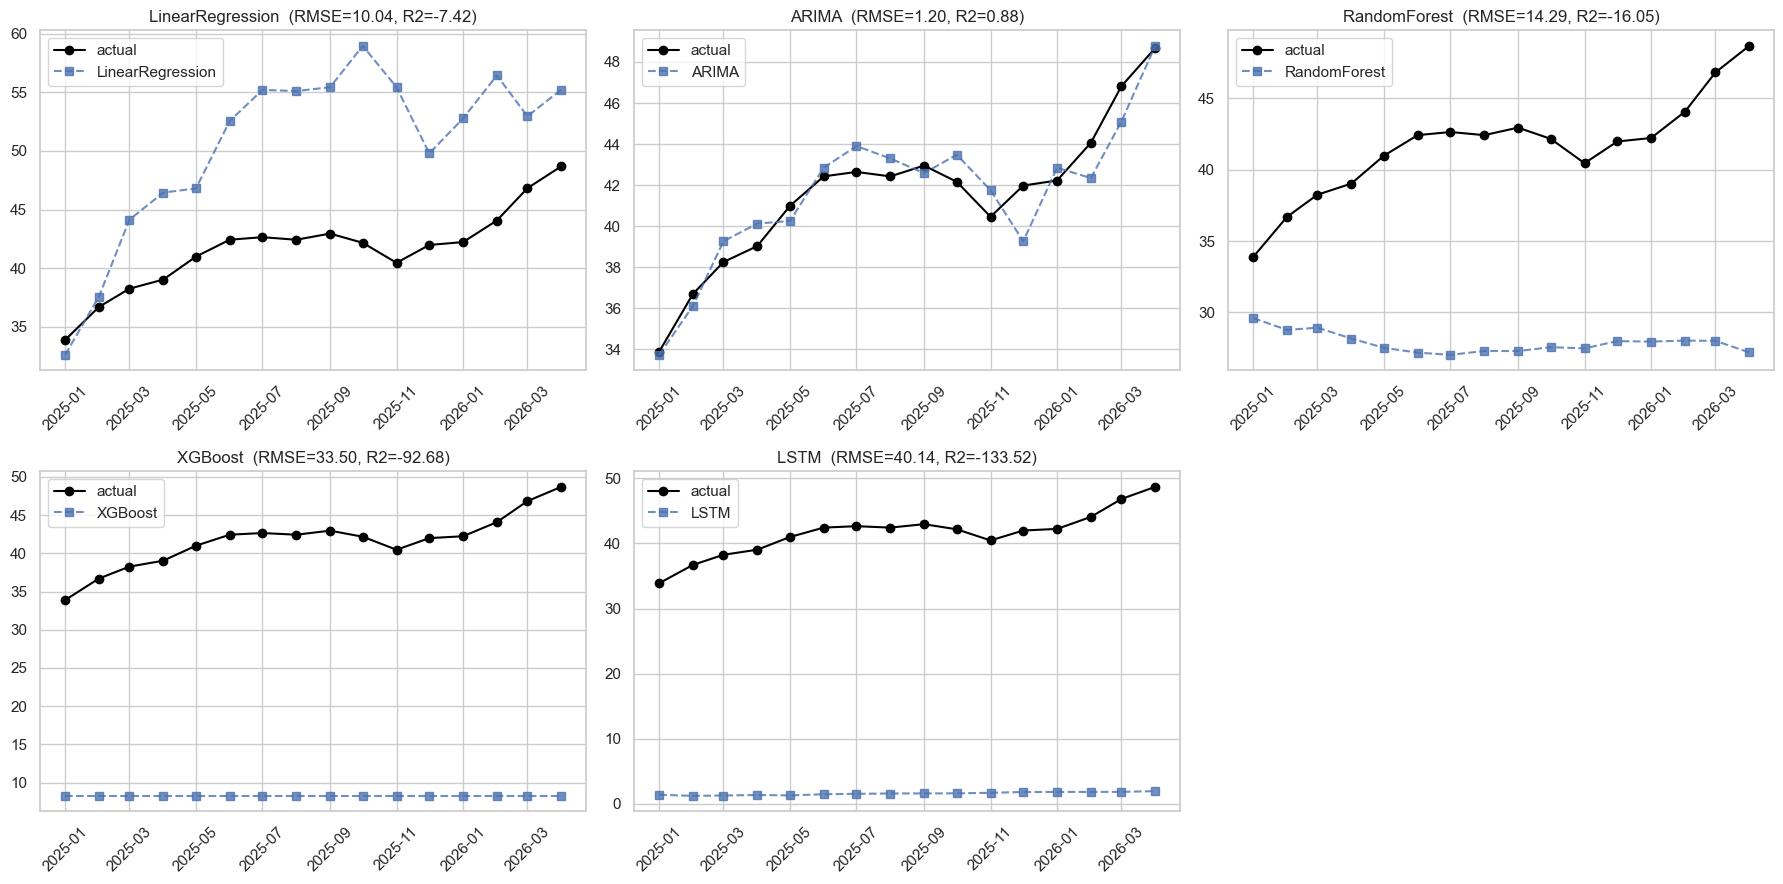

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, name in zip(axes.ravel(), results):
    ax.plot(pd.to_datetime(dates_test), y_test, "o-", label="actual", color="black")
    ax.plot(pd.to_datetime(dates_test), predictions[name], "s--", label=name, alpha=0.8)
    ax.set_title(f"{name}  (RMSE={results[name]['RMSE']:.2f}, R2={results[name]['R2']:.2f})")
    ax.tick_params(axis="x", rotation=45); ax.legend()
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

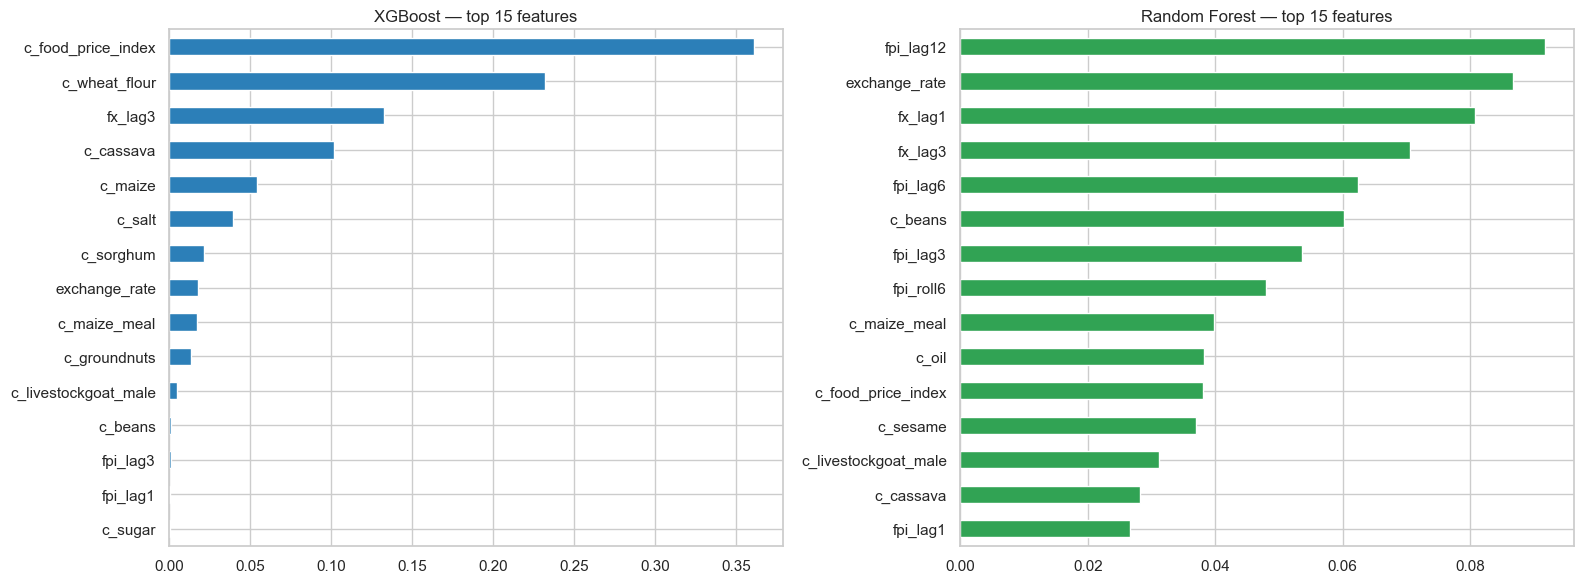

In [36]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 6))
imp_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values().tail(15)
imp_rf  = pd.Series(rf.feature_importances_, index=FEATURES).sort_values().tail(15)
imp_xgb.plot.barh(ax=a1, title="XGBoost — top 15 features", color="#2c7fb8")
imp_rf.plot.barh(ax=a2, title="Random Forest — top 15 features", color="#31a354")
plt.tight_layout(); plt.show()

## 13. Model Selection and Saving
Winner = meets **R² ≥ 0.75 AND MAPE ≤ 15%** with the lowest RMSE.
If none qualify, pick lowest RMSE overall and print a warning.
Saved to `ml-service/models/model.pkl` (+ `model_metadata.json`).

In [37]:
qualifying = {n: m for n, m in results.items() if m["R2"] >= 0.75 and m["MAPE"] <= 15.0}
if qualifying:
    winner = min(qualifying, key=lambda n: results[n]["RMSE"])
    print(f"Winner meeting criteria: {winner}")
else:
    winner = min(results, key=lambda n: results[n]["RMSE"])
    print(f"WARNING: no model met R2>=0.75 AND MAPE<=15%. "
          f"Falling back to lowest-RMSE model: {winner}")
print("winner metrics:", results[winner])

Winner meeting criteria: ARIMA
winner metrics: {'RMSE': 1.1965164869670288, 'MAE': 1.0002975804321053, 'MAPE': 2.389443589253124, 'R2': 0.8804780426204176}


In [38]:
# fitted-estimator lookup
fitted = {"LinearRegression": lin, "ARIMA": best_order, "RandomForest": rf,
          "XGBoost": xgb_model, "LSTM": lstm}

bundle = {"model_type": winner, "scaler": scaler,
          "feature_names": FEATURES, "target_name": TARGET,
          "uses_scaled_input": winner in ("LinearRegression", "LSTM")}

if winner == "LSTM":
    kpath = MODELS_DIR / "model_lstm.keras"
    lstm.save(kpath)
    bundle["keras_path"] = str(kpath); bundle["sequence_length"] = SEQ; bundle["model"] = None
elif winner == "ARIMA":
    bundle["arima_order"] = best_order; bundle["model"] = "arima_refit_per_inference"
else:
    bundle["model"] = fitted[winner]

joblib.dump(bundle, MODELS_DIR / "model.pkl")
print("saved ->", MODELS_DIR / "model.pkl")

saved -> /Users/apple/Documents/capstone-project/Lek/lek/ml-service/models/model.pkl


In [39]:
version_name = f"v1_{winner.lower()}_{datetime.now():%Y%m%d}"
metadata = {
    "version_name": version_name,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "rmse": round(results[winner]["RMSE"], 6),
    "mape": round(results[winner]["MAPE"], 6),
    "r2_score": round(results[winner]["R2"], 6),
    "feature_names": FEATURES,
    "target_name": TARGET,
    "training_data_range": {
        "start_date": str(pd.to_datetime(dates_train).min().date()),
        "end_date": str(pd.to_datetime(dates_train).max().date()),
    },
    "all_model_results": {n: {k: round(v, 6) for k, v in m.items()} for n, m in results.items()},
    "data_caveat": ("conflict (UCDP) and national CPI end 2024; oil ends Jan 2026 — "
                    "these features are forward/zero-filled across the 2025-2026 test window."),
}
with open(MODELS_DIR / "model_metadata.json", "w") as fh:
    json.dump(metadata, fh, indent=2)
print(json.dumps(metadata, indent=2))

{
  "version_name": "v1_arima_20260612",
  "trained_at": "2026-06-12T12:04:06",
  "rmse": 1.196516,
  "mape": 2.389444,
  "r2_score": 0.880478,
  "feature_names": [
    "c_food_price_index",
    "inflation_food_price_index",
    "c_beans",
    "c_cassava",
    "c_groundnuts",
    "c_livestockgoat_male",
    "c_livestocksheep_male",
    "c_maize",
    "c_maize_meal",
    "c_millet",
    "c_oil",
    "c_salt",
    "c_sesame",
    "c_sorghum",
    "c_sugar",
    "c_wheat_flour",
    "exchange_rate",
    "oil_production",
    "national_cpi",
    "pipeline_flowing",
    "is_lean_season",
    "season_ord",
    "fpi_lag1",
    "fpi_lag3",
    "fpi_lag6",
    "fpi_lag12",
    "fpi_roll3",
    "fpi_roll6",
    "fx_lag1",
    "fx_lag3",
    "oil_lag1",
    "conflict_events_ssd_lag1",
    "conflict_deaths_ssd_lag1",
    "conflict_events_sdn_lag1",
    "conflict_deaths_sdn_lag1",
    "m_1",
    "m_2",
    "m_3",
    "m_4",
    "m_5",
    "m_6",
    "m_7",
    "m_8",
    "m_9",
    "m_10",
    "m_1

In [40]:
# final acceptance summary
print("ACCEPTANCE CHECK")
print("  model.pkl exists           :", (MODELS_DIR / "model.pkl").exists())
print("  model_metadata.json exists :", (MODELS_DIR / "model_metadata.json").exists())
print("  master covers 2007-01->2026-05:",
      master["date"].min().date(), "->", master["date"].max().date())
print("  all 5 models produced metrics:", len(results) == 5)
ok = any(m["R2"] >= 0.75 and m["MAPE"] <= 15.0 for m in results.values())
print("  >=1 model R2>=0.75 & MAPE<=15%:", ok, "(reported honestly either way)")

ACCEPTANCE CHECK
  model.pkl exists           : True
  model_metadata.json exists : True
  master covers 2007-01->2026-05: 2007-01-01 -> 2026-04-01
  all 5 models produced metrics: True
  >=1 model R2>=0.75 & MAPE<=15%: True (reported honestly either way)
